In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

2799941


In [51]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [13]:
folder_path = "Data"

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

In [52]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  


def top_k_mask(matrix, k):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask[rows, cols] = 1
    mask[cols, rows] = 1

    return mask

In [15]:
stats=np.zeros((300,3))


for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=8.0)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)

    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            if isfinite[i][j]:

                d = int(dist[i, j])
                stats[d, 2] += 1  # total pairs at distance d

                if binary_map[i, j]==1:

                    if contact_map[i, j]==1:
                        #true positives
                        stats[d, 0] += 1

                    elif contact_map[i, j]==0:
                        #false positives
                        stats[d, 1] += 1
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)

/tmp/ipykernel_2780924/2004208958.py:38: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_2780924/2004208958.py:39: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


In [ ]:
def sample_noisy_contact_map_from_distance(
    distance_map,
    p_detect_by_r,
    K,
    threshold=8.0,
    seed=None,
):
    """
    Generate a noisy contact map using detection probabilities vs real distance.

    Parameters
    ----------
    distance_map : (L, L) array
        Real-valued distance matrix.
    p_detect_by_r : array-like
        p_detect_by_r[r] = probability of predicting a contact at distance r
        (r is assumed to be int(distance)).
    K : int
        Total number of predicted contacts
    threshold : float
        Distance threshold separating true (<= threshold) and false (> threshold).
    seed : int or None

    Returns
    -------
    new_map : (L, L) int8 array
    stats : dict
        Contains counts of true/false contacts.
    """
    rng = np.random.default_rng(seed)

    D = np.asarray(distance_map)
    L = D.shape[0]

    # --- consider only upper triangle (i < j)
    i, j = np.triu_indices(L, k=1)

    dvals = D[i, j]
    valid = np.isfinite(dvals)

    i = i[valid]
    j = j[valid]
    dvals = dvals[valid]

    # --- convert distances to integer bins
    r = np.floor(dvals).astype(int)
    r = np.clip(r, 0, len(p_detect_by_r) - 1)

    # --- weights from empirical detection probability
    w = p_detect_by_r[r].astype(float)

    # avoid degenerate case
    if np.all(w == 0):
        raise ValueError("All detection probabilities are zero.")

    # --- split into true / false according to threshold
    true_mask = dvals <= threshold
    false_mask = dvals > threshold

    # weights per group
    w_true = w[true_mask]
    w_false = w[false_mask]

    # --- total weight
    W_true = w_true.sum()
    W_false = w_false.sum()
    W_total = W_true + W_false

    if W_total == 0:
        raise ValueError("Total weight is zero.")

    # --- allocate number of contacts
    K_true = int(round(K * W_true / W_total))
    K_false = K - K_true

    # --- indices
    true_i, true_j = i[true_mask], j[true_mask]
    false_i, false_j = i[false_mask], j[false_mask]

    # --- safety checks
    K_true = min(K_true, len(true_i))
    K_false = min(K_false, len(false_i))

    # --- probabilities within each group
    if len(w_true) > 0:
        p_true = w_true / w_true.sum()
        idx_true = rng.choice(len(true_i), size=K_true, replace=False, p=p_true)
    else:
        idx_true = np.array([], dtype=int)

    if len(w_false) > 0:
        p_false = w_false / w_false.sum()
        idx_false = rng.choice(len(false_i), size=K_false, replace=False, p=p_false)
    else:
        idx_false = np.array([], dtype=int)

    # --- build output map
    new_map = np.zeros((L, L), dtype=np.int8)

    # true contacts
    ti = true_i[idx_true]
    tj = true_j[idx_true]
    new_map[ti, tj] = 1
    new_map[tj, ti] = 1

    # false contacts
    fi = false_i[idx_false]
    fj = false_j[idx_false]
    new_map[fi, fj] = 1
    new_map[fj, fi] = 1

    stats = {
        "K_total": K,
        "K_true": len(idx_true),
        "K_false": len(idx_false),
        "fraction_true": len(idx_true) / K if K > 0 else 0.0,
    }

    return new_map, stats

In [54]:
import numpy as np
import torch
from torch_geometric.data import Data

def build_graph_contact(noisy_contact_map, true_contact_map=None, sep_min=0):
    
    N = len(noisy_contact_map)

    # contact map to tensor
    noisy_contact_map = torch.tensor(noisy_contact_map, dtype=torch.float)

    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if true_contact_map is not None:
        true_contact_map = torch.tensor(true_contact_map, dtype=torch.float)
        known = torch.isfinite(true_contact_map)
        labels = (known & (true_contact_map == 1)).float()
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok
     # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    edge_index = torch.stack([src, dst], dim=0)
    edge_attr = noisy_contact_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1) 
        
    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,                 # binary contact labels
        edge_mask=mask,      # valid + long-range
        pair_mask=pair_mask, # only one direction per pair
        L=N
    )

In [18]:
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)
from sequenceHandler import distance_map_PDB

folder_path = "PDB"
p_detect_by_r = total_percentage

all_data = []
for file in os.listdir(folder_path):
    pdb_path = os.path.join(folder_path, file)
    chain_id = "A"
    output_map_file = "None"  

    try:
        distance_map, __ = distance_map_PDB(pdb_path, chain_id, output_map_file)
        true_contact_map = contact_from_distance(distance_map, threshold=8.0)

        L= distance_map.shape[0]
        K = 5 * L
        noisy_contact_map, __ = sample_noisy_contact_map_from_distance(distance_map,p_detect_by_r,K,threshold=8.0,seed=1)
        data = build_graph_contact(noisy_contact_map, true_contact_map)
        all_data.append(data)
    except:
        print(f"Some error occurred in the sequence {file}")


torch.save(all_data, "all_data_likeDCA.pt") 

Some error occurred in the sequence PF07714.pdb
Some error occurred in the sequence PF00016.pdb
Some error occurred in the sequence PF00031.pdb
Some error occurred in the sequence PF00044.pdb
Some error occurred in the sequence PF00046.pdb
Some error occurred in the sequence PF00050.pdb
Some error occurred in the sequence PF00058.pdb
Some error occurred in the sequence PF00069.pdb
Some error occurred in the sequence PF00073.pdb
Some error occurred in the sequence PF00082.pdb
Some error occurred in the sequence PF00095.pdb
Some error occurred in the sequence PF00096.pdb
Some error occurred in the sequence PF00098.pdb
Some error occurred in the sequence PF00101.pdb
Some error occurred in the sequence PF00111.pdb
Some error occurred in the sequence PF00121.pdb
Some error occurred in the sequence PF00124.pdb
Some error occurred in the sequence PF00130.pdb
Some error occurred in the sequence PF00157.pdb
Some error occurred in the sequence PF00170.pdb
Some error occurred in the sequence PF00

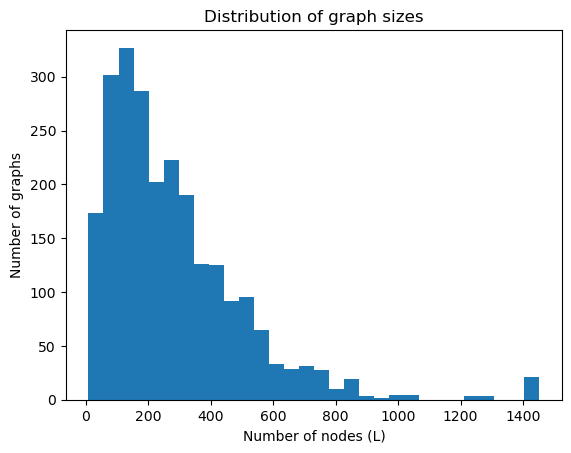

Biggest graph index: 967
Max edges: 2106852
Nodes: 1452


In [23]:

all_data = torch.load("all_data_likeDCA.pt",weights_only=False)   
import matplotlib.pyplot as plt

lengths = [data.num_nodes for data in all_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

max_edges = 0
max_idx = -1

for i, data in enumerate(all_data):
    n_edges = data.edge_index.size(1)
    if n_edges > max_edges:
        max_edges = n_edges
        max_idx = i

print("Biggest graph index:", max_idx)
print("Max edges:", max_edges)
print("Nodes:", all_data[max_idx].num_nodes)

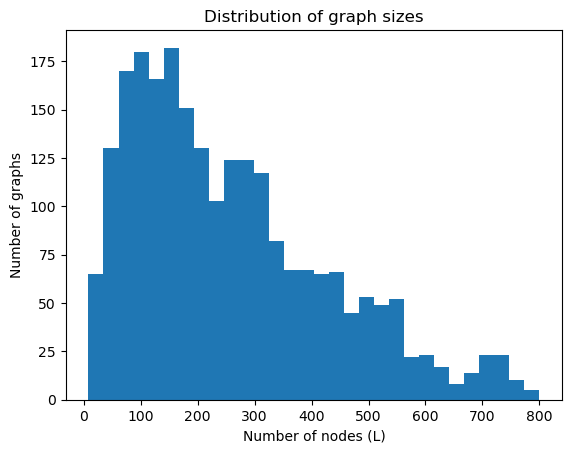

In [26]:
MAX_NODES = 800

filtered_data = [data for data in all_data if data.num_nodes <= MAX_NODES]

lengths = [data.num_nodes for data in filtered_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

In [27]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(filtered_data, test_size=0.2, random_state=1)


train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [28]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [29]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, edge_in_ch = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:
            self.edge_norms.append(LayerNorm(edge_in_ch))
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = edge_in_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.ReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # one logit
        )


    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs)):
            x_in = x
            e_in = edge_attr

            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

        # Final projection to output space
        edge_attr = self.edge_head(edge_attr)

        return x, edge_attr

In [30]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [31]:
def average_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_edges = 0
    total_batches= 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss += loss.item() * n_edges
            total_edges += n_edges
            total_batches += 1

    return total_loss / max(total_edges, 1)


In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGNN(node_in_ch=16, edge_in_ch=1, hidden_ch=25, mlp_hidden_ch=12, GNN_layers=3).to(device)

pos_weight = compute_pos_weight(train_loader, device)
print("pos_weight:", pos_weight.item())
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []


best_val_loss = float('inf')
patience = 10
epochs_no_improve = 0
save_path = "best_model_cc_likeDCA.pt"

for epoch in range(10):

    model.train()

    total_loss = 0.0
    total_edges = 0
    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        _, pred_logits = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        true_contacts = batch.y.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss = loss_fn(pred_logits[mask], true_contacts[mask])

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        optimizer.step()

    train_loss = total_loss / max(total_edges, 1)
    val_loss = average_loss(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

pos_weight: 14.502667427062988
Epoch 0: Train Loss=0.6896, Val Loss=0.6806
Epoch 1: Train Loss=0.6879, Val Loss=0.6847
Epoch 2: Train Loss=0.6853, Val Loss=0.6778
Epoch 3: Train Loss=0.6887, Val Loss=0.6827
Epoch 4: Train Loss=0.6851, Val Loss=0.6808
Epoch 5: Train Loss=0.6846, Val Loss=0.6716
Epoch 6: Train Loss=0.6855, Val Loss=0.6800
Epoch 7: Train Loss=0.6843, Val Loss=0.6758
Epoch 8: Train Loss=0.6837, Val Loss=0.6788
Epoch 9: Train Loss=0.6828, Val Loss=0.6751


In [33]:
#save_path = "best_model_cc_likeDCA.pt"
save_path = "best_model_contacts_contacts.pt"
state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

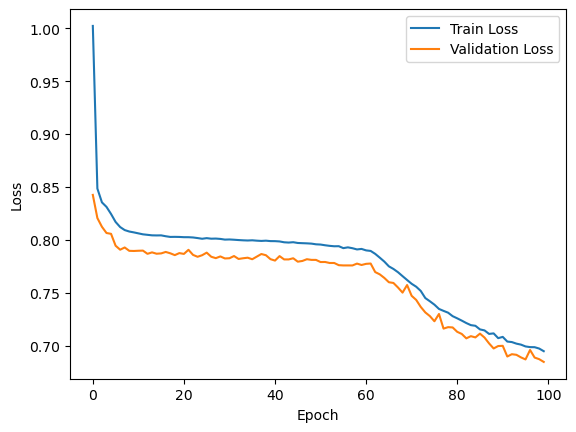

In [34]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Precision of the GNN: 0.7082381050241107
Recall of the GNN: 0.47780226182148683
F1 of the GNN: 0.570634487574296
AUPRC of the GNN: 0.62542503920465
Validation ROC AUC GNN: 0.9148871900765408


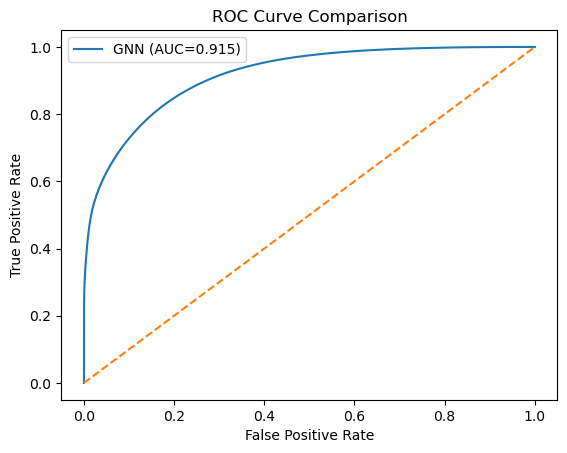

PR AUC GNN: 0.6254250473818322


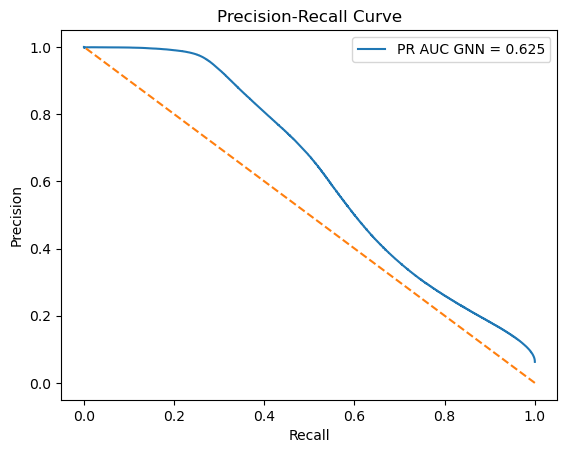

In [57]:
from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve

model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)


threshold=0.9

pred_contacts = (all_probs >= threshold).int().numpy()
true_contacts = all_true.int().numpy()

precision = precision_score(true_contacts, pred_contacts, zero_division=0)
recall = recall_score(true_contacts, pred_contacts, zero_division=0)
f1 = f1_score(true_contacts, pred_contacts, zero_division=0)
auprc = average_precision_score(true_contacts, all_probs.numpy())

print(f"Precision of the GNN: {np.mean(precision)}")
print(f"Recall of the GNN: {np.mean(recall)}")
print(f"F1 of the GNN: {np.mean(f1)}")
print(f"AUPRC of the GNN: {np.mean(auprc)}")



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [58]:

def topk_L_precision(model, loader, device, ratio=1.0):
    model.eval()
    per_graph_precisions = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, logits = model(batch)

            probs = torch.sigmoid(logits.squeeze(-1))
            true_contacts = batch.y.squeeze(-1)

            valid_mask = batch.edge_mask & batch.pair_mask

            # graph id for each edge
            edge_graph_id = batch.batch[batch.edge_index[0]]

            num_graphs = batch.num_graphs

            for g in range(num_graphs):
                graph_mask = valid_mask & (edge_graph_id == g)

                probs_g = probs[graph_mask]
                true_g = true_contacts[graph_mask]

                if probs_g.numel() == 0:
                    continue

                # length of the protein
                L = int(batch.L[g]) if torch.is_tensor(batch.L) else int(batch.L)

                k = max(1, int(L * ratio))
                k = min(k, probs_g.numel())

                top_idx = torch.topk(probs_g, k=k).indices
                #knumber of true contacts in top-k​/k
                precision_g = (true_g[top_idx] > 0.5).float().mean().item()

                per_graph_precisions.append(precision_g)

    return float(np.mean(per_graph_precisions)), per_graph_precisions

print("Top-k*L precision:", topk_L_precision(model, test_loader, device, ratio=5)[0])

Top-k*L precision: 0.8679604606914316


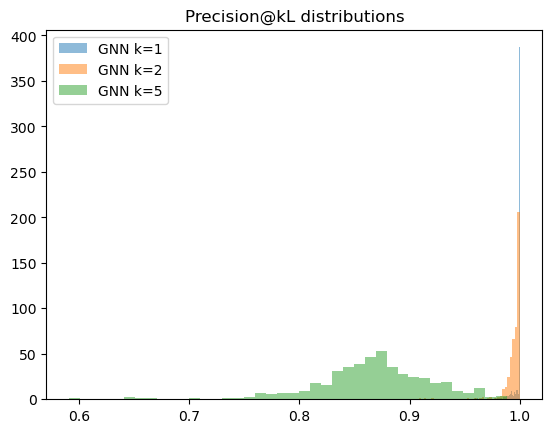

In [59]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, alpha=0.5, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [60]:
k=5
precision= topk_L_precision(model, test_loader, device, ratio=k)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))

[0.8148148059844971, 0.8758620619773865, 0.6422500014305115, 0.8523985147476196, 0.8848276138305664, 0.9009009003639221, 0.8409448862075806, 0.904347836971283, 0.891715943813324, 0.878646969795227, 0.8565657138824463, 0.8294915556907654, 0.863261342048645, 0.9249999523162842, 0.8593059778213501, 0.8612403273582458, 0.8897260427474976, 0.9435999989509583, 0.8354167342185974, 0.8349869251251221, 0.9374150037765503, 0.9148648977279663, 0.8472392559051514, 0.9409691691398621, 0.8620031476020813, 0.8313900828361511, 0.8896551728248596, 0.836363673210144, 0.9346153736114502, 0.8514285683631897, 0.9296296238899231, 0.864625871181488, 0.8751322627067566, 0.8977168798446655, 0.8294118046760559, 0.9180000424385071, 0.8085293769836426, 0.8766839504241943, 0.8690058588981628, 0.9609195590019226, 0.8778946995735168, 0.7785365581512451, 0.9155172109603882, 0.8883280754089355, 0.8770685195922852, 0.8114712834358215, 0.8770318031311035, 0.9000000357627869, 0.7708737850189209, 0.9293065071105957, 0.825

In [61]:
def graph_to_matrix(data, values):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

Data(x=[271, 16], edge_index=[2, 73170], edge_attr=[73170, 1], y=[73170, 1], edge_mask=[73170], pair_mask=[73170], L=271)


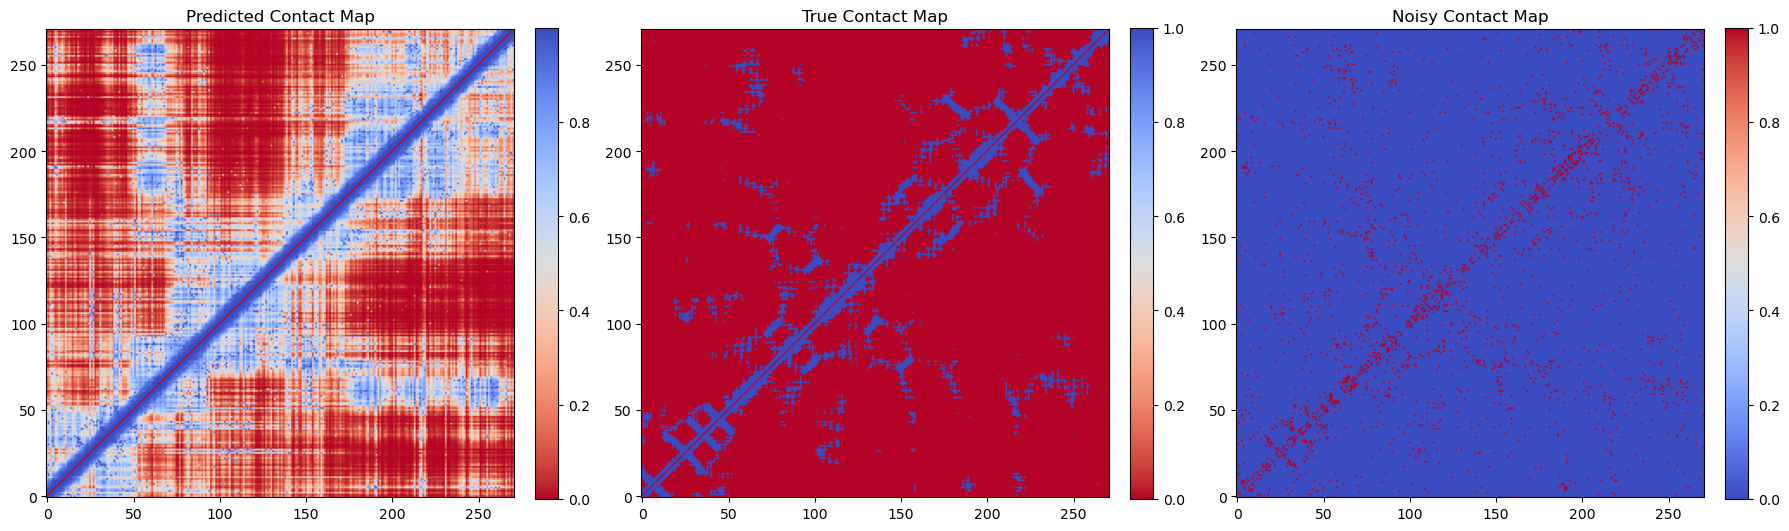

In [62]:
pos=3
#worst case

i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)

mask = batch.edge_mask & batch.pair_mask

scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.8
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [64]:
###test on DCA-like data

folder_path = "Data"

dca_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        k = 5*len(sequence)  
        binary_map = top_k_mask(contact_map_DCA, k)
        
        data = build_graph_contact(binary_map, true_contact_map)
        
        dca_data.append(data)

test_dca_loader = DataLoader(dca_data, batch_size=1, shuffle=False)

Precision of the GNN: 0.5953246496905252
Recall of the GNN: 0.4924067255625823
F1 of the GNN: 0.5389967929031942
AUPRC of the GNN: 0.5511373650436795
Validation ROC AUC GNN: 0.8636399173988899


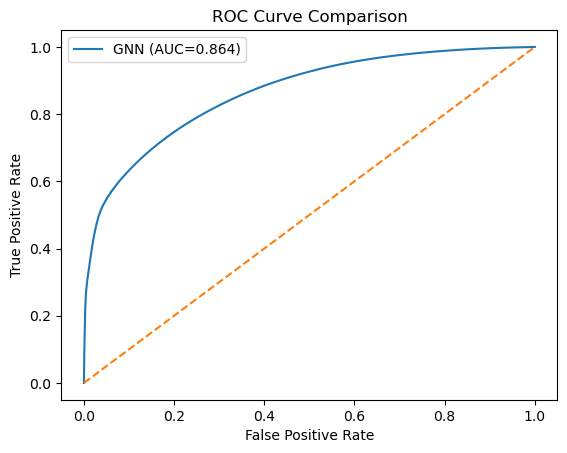

PR AUC GNN: 0.5511359141167925


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


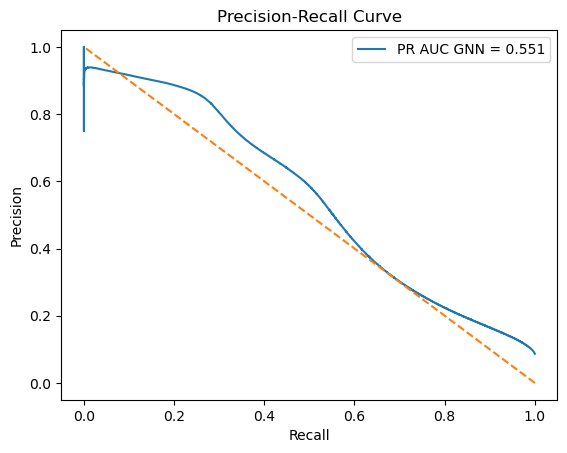

In [65]:
from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve

model.eval()

all_probs = []
all_true = []

for batch in test_dca_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)


threshold=0.9

pred_contacts = (all_probs >= threshold).int().numpy()
true_contacts = all_true.int().numpy()

precision = precision_score(true_contacts, pred_contacts, zero_division=0)
recall = recall_score(true_contacts, pred_contacts, zero_division=0)
f1 = f1_score(true_contacts, pred_contacts, zero_division=0)
auprc = average_precision_score(true_contacts, all_probs.numpy())

print(f"Precision of the GNN: {np.mean(precision)}")
print(f"Recall of the GNN: {np.mean(recall)}")
print(f"F1 of the GNN: {np.mean(f1)}")
print(f"AUPRC of the GNN: {np.mean(auprc)}")



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [72]:
def precision_at_kL_dca_per_graph(batch, k):
    scores = batch.edge_attr.squeeze(-1)  # DCA scores
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask & batch.pair_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    precisions = []

    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        L = batch.L[g].item() if isinstance(batch.L, torch.Tensor) else batch.L

        kL = int(k * L)
        kL = min(kL, g_scores.numel())

        if kL == 0:
            continue

        topk_idx = torch.topk(g_scores, kL).indices
        topk_true = g_true[topk_idx]

        precision = topk_true.float().mean().item()
        precisions.append(precision)

    return precisions

Top-k*L precision DCA: 0.5428202915103044
Top-k*L precision GNN: 0.7316224371914364


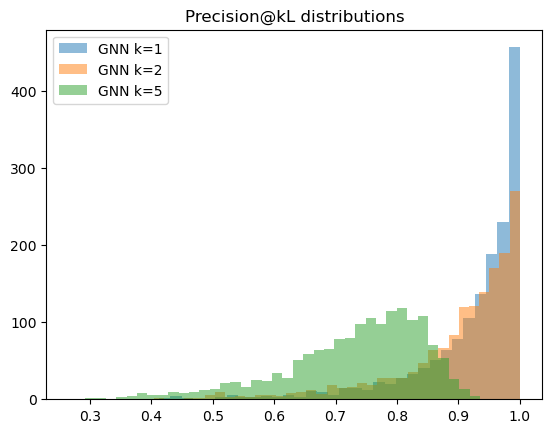

[0.8603773713111877, 0.8123077154159546, 0.8566038012504578, 0.880519449710846, 0.7230769395828247, 0.6083333492279053, 0.699999988079071, 0.7982906103134155, 0.8537634611129761, 0.5358024835586548, 0.8972973227500916, 0.7441441416740417, 0.916883111000061, 0.8379486799240112, 0.3390476107597351, 0.7078431844711304, 0.46410685777664185, 0.7107316851615906, 0.736842155456543, 0.8241379261016846, 0.7847618460655212, 0.7658536434173584, 0.7909090518951416, 0.8142857551574707, 0.7833333611488342, 0.8329113721847534, 0.6793892979621887, 0.8652482032775879, 0.5296552181243896, 0.5387755036354065, 0.803636372089386, 0.7259259819984436, 0.7752066254615784, 0.611347496509552, 0.6752475500106812, 0.7286486625671387, 0.8030075430870056, 0.5666666626930237, 0.8186046481132507, 0.8242104649543762, 0.5544186234474182, 0.702347457408905, 0.8472973108291626, 0.8660550713539124, 0.7010225057601929, 0.8261628150939941, 0.802020251750946, 0.585990309715271, 0.826407790184021, 0.5144000053405762, 0.701265

In [75]:
k=5.0 
precision=[]
for batch in test_dca_loader:
        batch = batch.to(device)
        _, pred_logits = model(batch)
        vals= precision_at_kL_dca_per_graph(batch, k)
        precision.append(vals)


print("Top-k*L precision DCA:", np.mean(precision))
print("Top-k*L precision GNN:", topk_L_precision(model, test_dca_loader, device, ratio=5)[0])

k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_dca_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, alpha=0.5, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

k=5
precision= topk_L_precision(model, test_dca_loader, device, ratio=k)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))

Data(x=[104, 16], edge_index=[2, 10712], edge_attr=[10712, 1], y=[10712, 1], edge_mask=[10712], pair_mask=[10712], L=104)


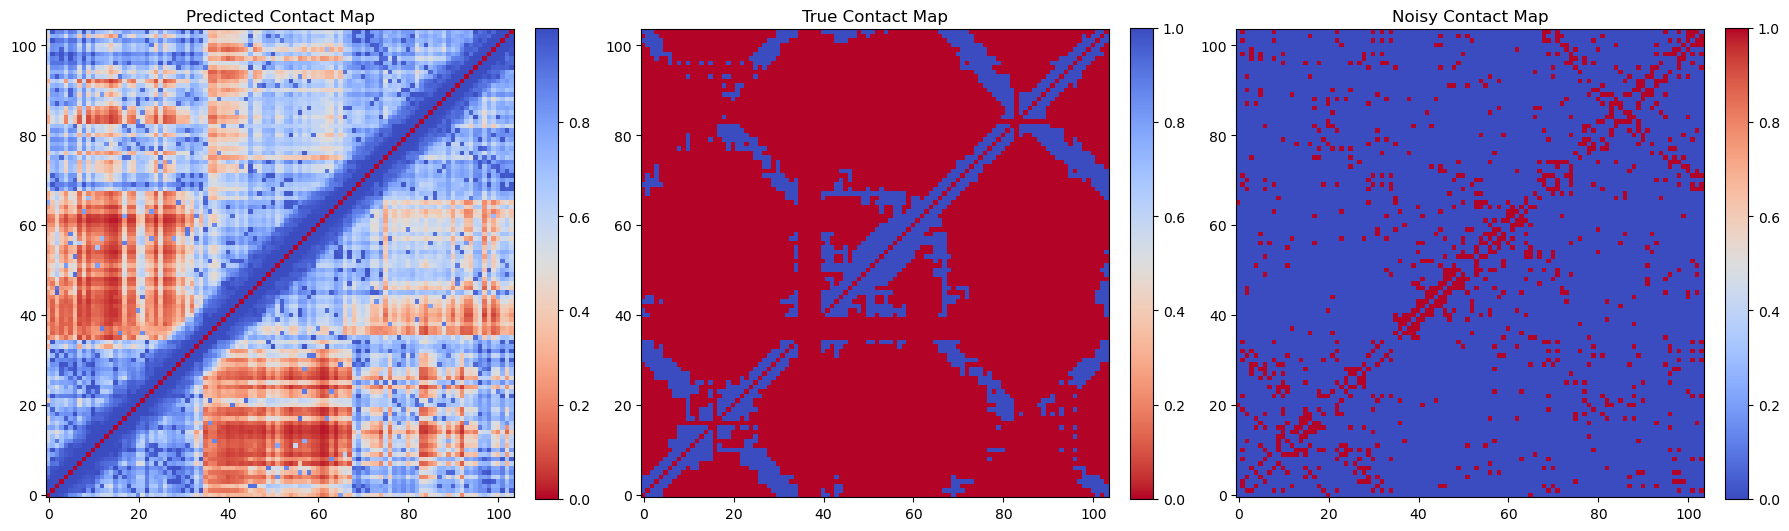

In [76]:
pos=4
#worst case

i=0
with torch.no_grad():
    for batch in test_dca_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=dca_data[pos]
print(batch)

mask = batch.edge_mask & batch.pair_mask

scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.8
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()